In [1]:
#!pip install sympy networkx

# Modelo Lotka-Volterra

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import ipywidgets as widgets
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.signal import find_peaks
from IPython.display import display, Markdown

print('ipywidgets', widgets.__version__)   # debe ser >= 7.6 / 8.x
plt.rcParams.update({'figure.figsize': (9.5, 4.6), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 11})

# ---------------- Parámetros canónicos del modelo de juguete ----------------
P0 = dict(alpha=1.1, beta=0.4, gamma=0.10, delta=0.40)   # presa x, depredador y

def lv_rhs(t, z, p):
    x, y = z
    return [p['alpha']*x - p['beta']*x*y,
            p['gamma']*x*y - p['delta']*y]

def simulate(p, x0, y0, t_end=60.0, npts=1500, t_eval=None, rtol=1e-8, atol=1e-8):
    """Integración numérica (LSODA) del sistema."""
    if t_eval is None:
        t_eval = np.linspace(0.0, t_end, npts)
    sol = solve_ivp(lv_rhs, (0.0, t_eval[-1]), [x0, y0], args=(p,),
                    t_eval=t_eval, rtol=rtol, atol=atol, method='LSODA')
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.t, sol.y[0], sol.y[1]

def eq_coexist(p):
    """Punto fijo no trivial: x* = delta/gamma, y* = alpha/beta."""
    return p['delta']/p['gamma'], p['alpha']/p['beta']

def first_integral(x, y, p):
    """Cantidad conservada V = gamma*x - delta*ln x + beta*y - alpha*ln y."""
    return p['gamma']*x - p['delta']*np.log(x) + p['beta']*y - p['alpha']*np.log(y)

def period_lin(p):
    """Periodo linealizado: 2*pi/sqrt(alpha*delta)."""
    return 2*np.pi/np.sqrt(p['alpha']*p['delta'])

def peak_times(t, v, rel_prom=0.10, min_span_frac=0.05):
    """Máximos locales robustos al ruido (prominencia y distancia mínimas)."""
    span = v.max() - v.min()
    dt = max(t[1] - t[0], 1e-12)
    dist = max(2, int(min_span_frac*(t[-1] - t[0]) / dt))
    idx, _ = find_peaks(v, prominence=rel_prom*span, distance=dist)
    return t[idx]

def sim_period(t, v):
    tp = peak_times(t, v)
    return float(np.mean(np.diff(tp))) if tp.size >= 2 else np.nan

def interactive_plot(controls, box, plot_func):
    """Helper: reconstruye la figura dentro de un Output al cambiar cualquier widget."""
    out = widgets.Output()
    def _update(_=None):
        out.clear_output(wait=True)
        with out:
            fig = plot_func(**{name: w.value for name, w in controls.items()})
            plt.show()
            plt.close(fig)
    for w in controls.values():
        w.observe(_update, names='value')
    _update()
    display(box, out)

display(Markdown("✅ **Setup listo.** Modelo: $\\dot x=\\alpha x-\\beta xy$,  $\\dot y=\\gamma xy-\\delta y$."))

ipywidgets 8.1.7


✅ **Setup listo.** Modelo: $\dot x=\alpha x-\beta xy$,  $\dot y=\gamma xy-\delta y$.

# Paso 1 · Representación visual de la red de reacciones

El modelo abstracto se escribe como una **red de reacciones (procesos)** con cinética de masa/acción
modificada. Cada reacción $R_i$ tiene una **ley de velocidad** $v_i$ y contribuye con términos
específicos a las ecuaciones de balance:

| Reacción | Esquema | Velocidad $v_i$ | Contribución a las EDOs |
|---|---|---|---|
| R1 | $\emptyset \rightarrow P$ | $v_1=\alpha x$ | $+\alpha x$ en $\dot x$ |
| R2 | $P \rightarrow \emptyset$ (modificador: $D$) | $v_2=\beta x y$ | $-\beta x y$ en $\dot x$ |
| R3 | $D \rightarrow 2D$ (modificador: $P$) | $v_3=\gamma x y$ | $+\gamma x y$ en $\dot y$ |
| R4 | $D \rightarrow \emptyset$ | $v_4=\delta y$ | $-\delta y$ en $\dot y$ |

Las flechas **punteadas grises** son *modificadores*: la especie afecta la velocidad de la reacción
sin consumirse en ella (el depredador "cataliza" la muerte de la presa en R2).

**Uso del widget:** el dropdown resalta cada reacción (no hay sliders: la elección es categórica,
no continua). **Interpretación esperada:** al resaltar $R_i$ se ve exactamente qué flechas del
diagrama generan cada término de las ecuaciones del Paso 2.

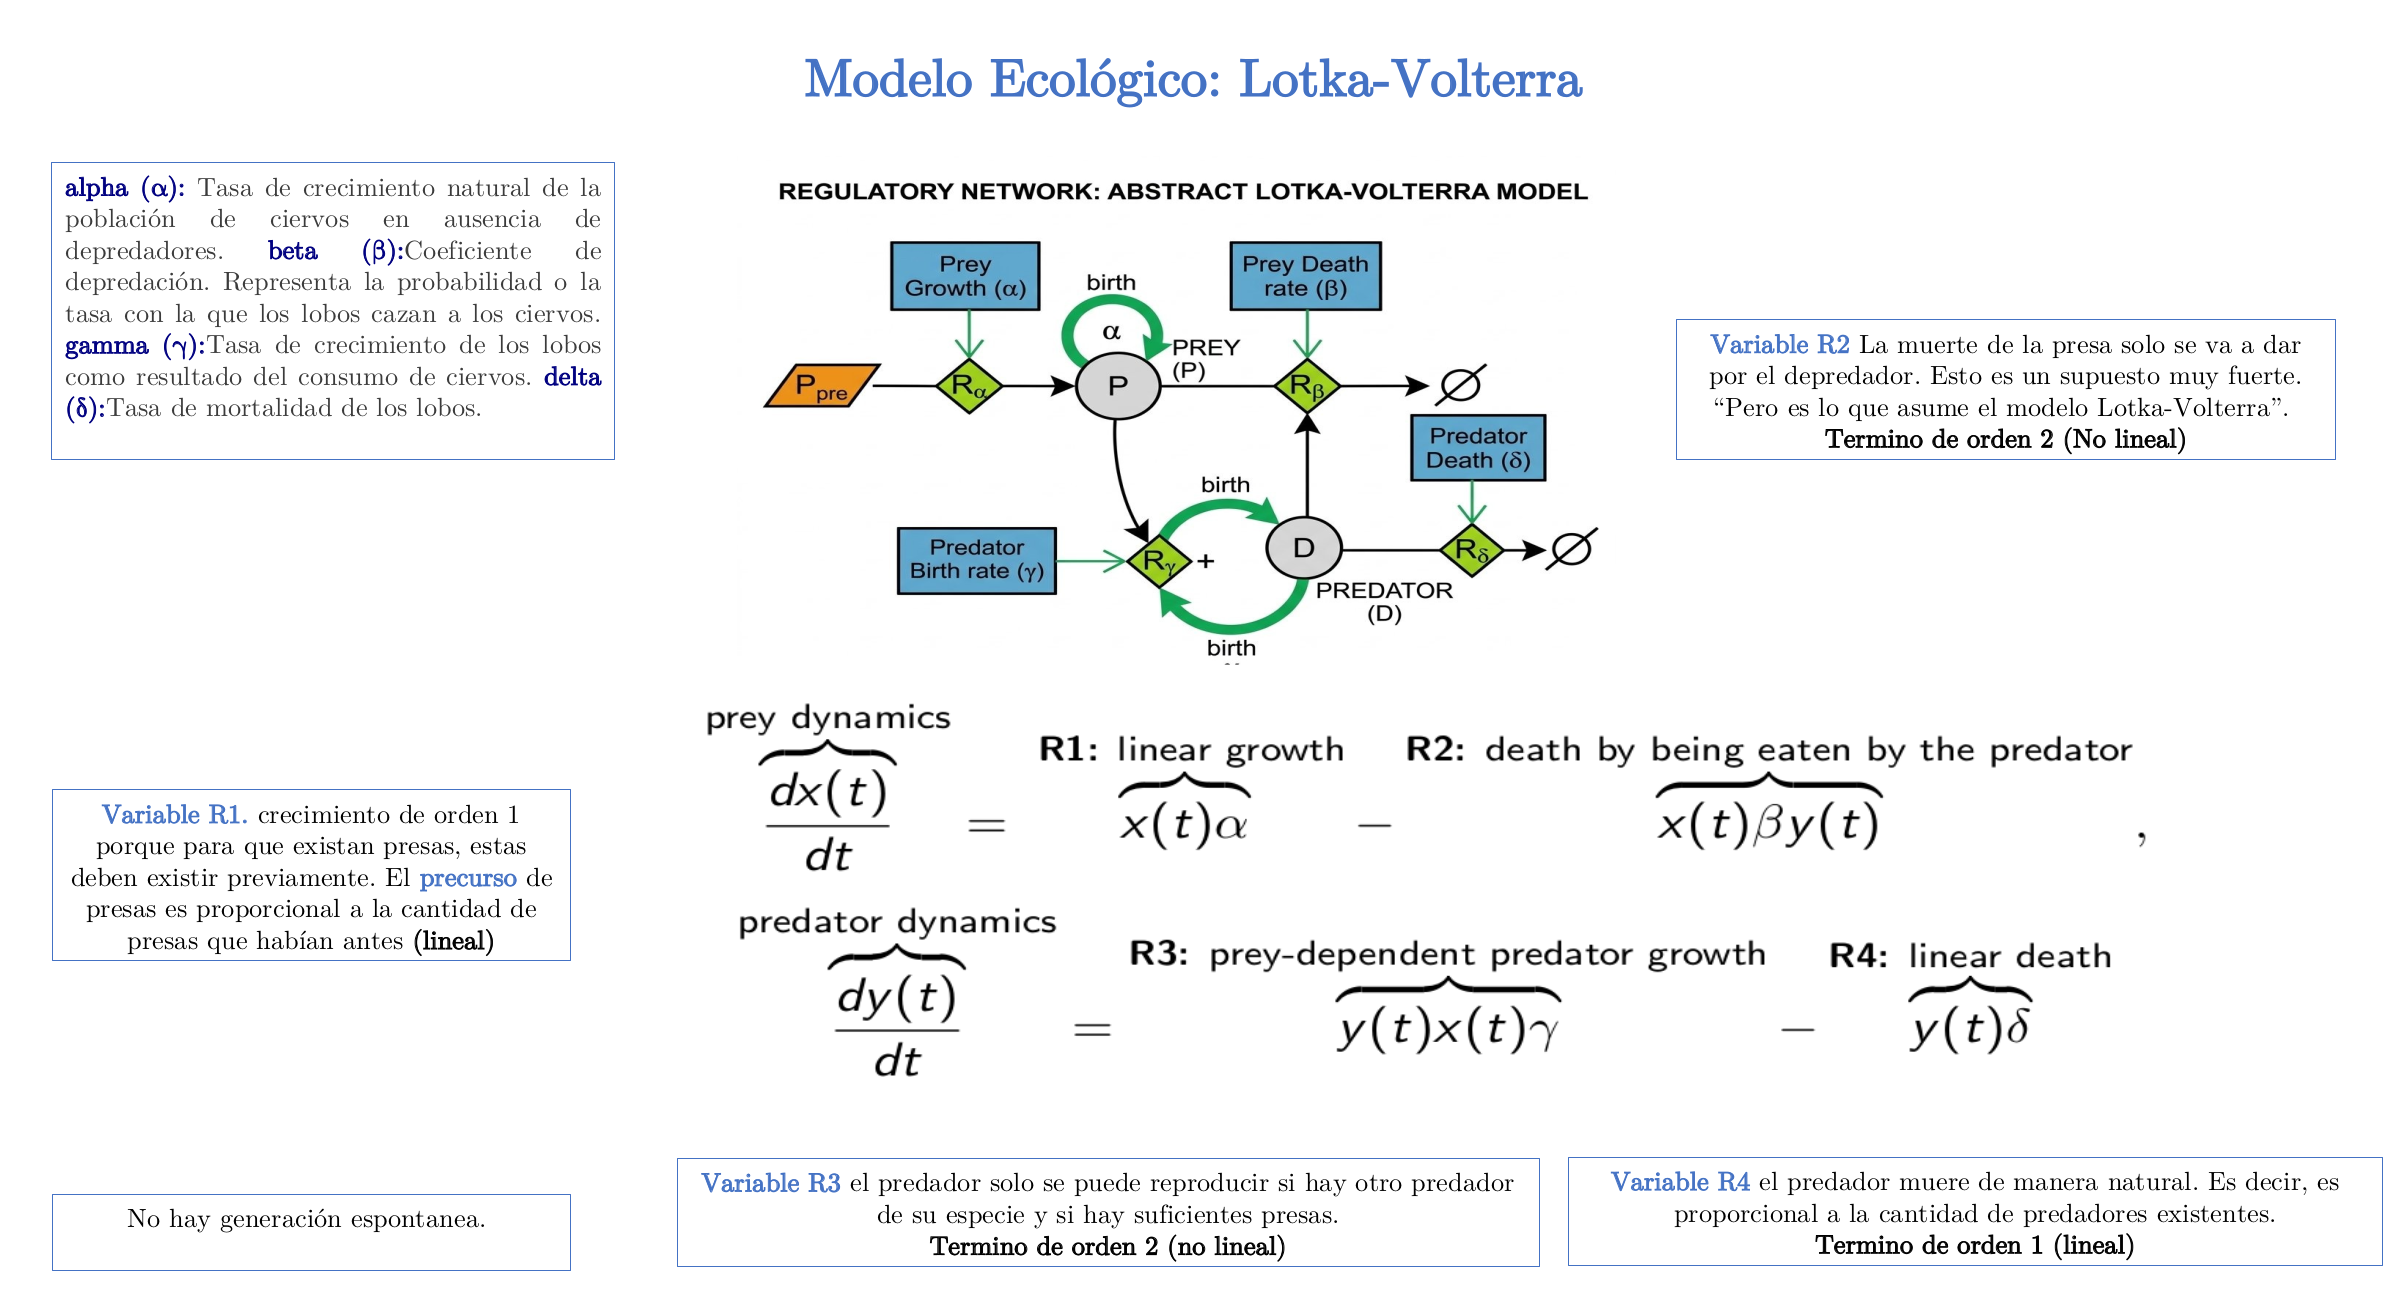

In [14]:
RX_INFO = {
 'R1': (r'$\emptyset \rightarrow P$',           r'$v_1=\alpha x$',   r'$+\alpha x$ en $dx/dt$'),
 'R2': (r'$P \rightarrow \emptyset$  (mod: D)', r'$v_2=\beta x y$',  r'$-\beta x y$ en $dx/dt$'),
 'R3': (r'$D \rightarrow 2D$  (mod: P)',        r'$v_3=\gamma x y$', r'$+\gamma x y$ en $dy/dt$'),
 'R4': (r'$D \rightarrow \emptyset$',           r'$v_4=\delta y$',   r'$-\delta y$ en $dy/dt$'),
}

def draw_network(highlight='Ninguna'):
    fig, ax = plt.subplots(figsize=(10.5, 5.4))
    ax.set_xlim(0, 10.8); ax.set_ylim(0, 6.2); ax.axis('off')
    P = np.array([4.0, 3.8]); D = np.array([7.2, 1.6])

    for pos, name, lab in [(P, 'P', 'PREY (P)'), (D, 'D', 'PREDATOR (D)')]:
        ax.add_patch(plt.Circle(pos, 0.38, fc='#d9d9d9', ec='k', lw=1.5, zorder=3))
        ax.text(pos[0], pos[1], name, ha='center', va='center', fontsize=13, zorder=4)
        ax.text(pos[0], pos[1]-0.8, lab, ha='center', fontsize=9)

    def arrow(p1, p2, color='k', lw=1.6, ls='-', sA=8, sB=8, rad=0.0):
        ax.annotate('', xy=p2, xytext=p1, arrowprops=dict(
            arrowstyle='-|>', color=color, lw=lw, linestyle=ls,
            shrinkA=sA, shrinkB=sB, connectionstyle=f'arc3,rad={rad}'), zorder=2)

    c  = lambda r: '#e66101' if highlight == r else 'k'
    lw = lambda r: 3.2 if highlight == r else 1.6

    # R1: fuente -> P
    arrow((1.0, 3.8), P, c('R1'), lw('R1'))
    ax.text(0.75, 3.8, r'$\emptyset$', fontsize=16, ha='center', va='center')
    ax.text(2.2, 4.05, r'$v_1=\alpha x$', color=c('R1'), fontsize=11, weight='bold')
    # R2: P -> vacio, modificador D
    arrow(P, (9.6, 3.8), c('R2'), lw('R2'))
    ax.text(9.9, 3.8, r'$\emptyset$', fontsize=16, ha='center', va='center')
    ax.text(5.5, 4.05, r'$v_2=\beta x y$', color=c('R2'), fontsize=11, weight='bold')
    arrow(D, (6.6, 3.5), 'gray', 1.2, '--', sA=10, sB=2)
    # R3: autolazo en D (nacimiento del depredador), modificador P
    arrow((7.55, 1.30), (6.85, 1.30), c('R3'), lw('R3'), sA=6, sB=6, rad=1.35)
    ax.text(7.2, 0.35, r'$v_3=\gamma x y$', color=c('R3'), fontsize=11,
            weight='bold', ha='center')
    arrow(P, (6.4, 1.0), 'gray', 1.2, '--', sA=10, sB=2)
    # R4: D -> vacio
    arrow(D, (9.6, 1.6), c('R4'), lw('R4'))
    ax.text(9.9, 1.6, r'$\emptyset$', fontsize=16, ha='center', va='center')
    ax.text(8.2, 1.9, r'$v_4=\delta y$', color=c('R4'), fontsize=11, weight='bold')

    ax.set_title('REGULATORY NETWORK: abstract Lotka–Volterra', weight='bold')
    if highlight in RX_INFO:
        s, v, e = RX_INFO[highlight]
        ax.text(0.2, 5.7, f'{highlight}:  {s}    {v}    ⇒    {e}',
                fontsize=12, color='#e66101', weight='bold')
    ax.text(0.2, 0.1, 'flechas punteadas grises = modificador (no se consume)',
            fontsize=8, color='gray')
    return fig

w_rx = widgets.Dropdown(options=['Ninguna', 'R1', 'R2', 'R3', 'R4'],
                        value='Ninguna', description='Resaltar reacción:')
interactive_plot({'highlight': w_rx}, widgets.VBox([w_rx]), draw_network)

Output()

# Paso 2 · Representación matemática (ley de acción de masas)

Cada especie suma los flujos que la crean y resta los que la destruyen:

$$\frac{dx}{dt}=\underbrace{\alpha x}_{R1}-\underbrace{\beta x y}_{R2},
\qquad
\frac{dy}{dt}=\underbrace{\gamma x y}_{R3}-\underbrace{\delta y}_{R4}$$

- **R1 y R4** son de *orden 1* (lineales): una presa/depredador debe existir previamente para
  reproducirse/morir → término proporcional a la propia población.
- **R2 y R3** son de *orden 2* (no lineales): requieren el **encuentro** presa–depredador
  (probabilidad de encuentro $\propto x\cdot y$). Son los términos que *acoplan* el sistema.

**Uso del widget:** sliders de $x$ y $y$ (estado instantáneo). **Interpretación esperada:** con
$y=0$ el término R2 se anula y $\dot x=\alpha x$ (crecimiento exponencial); si $x$ o $y$ es 0, R3 se
anula y el depredador decae como $-\delta y$ ("no hay generación espontánea"). Mueve los sliders y
observa cómo el término de orden 2 domina cuando ambas poblaciones son grandes.

In [15]:
w_x = widgets.FloatSlider(value=8.0, min=0.0, max=15.0, step=0.1,
                          description='x (presas)', continuous_update=False)
w_y = widgets.FloatSlider(value=3.0, min=0.0, max=10.0, step=0.1,
                          description='y (depred.)', continuous_update=False)

def terms_plot(x, y):
    p = P0
    R1, R2 = p['alpha']*x, p['beta']*x*y
    R3, R4 = p['gamma']*x*y, p['delta']*y
    dxdt, dydt = R1 - R2, R3 - R4
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
    vals = [R1, -R2, R3, -R4]
    labs = [r'$+\alpha x$ (R1)', r'$-\beta xy$ (R2)', r'$+\gamma xy$ (R3)', r'$-\delta y$ (R4)']
    cols = ['#1a9850' if v >= 0 else '#d73027' for v in vals]
    axes[0].bar(labs, vals, color=cols)
    axes[0].axhline(0, color='k', lw=0.8)
    axes[0].set_title(f'Términos individuales  (x={x:.1f}, y={y:.1f})')
    axes[0].tick_params(axis='x', labelsize=9)
    axes[1].bar(['dx/dt', 'dy/dt'], [dxdt, dydt], color=['#4575b4', '#9970ab'])
    axes[1].axhline(0, color='k', lw=0.8)
    for i, v in enumerate([dxdt, dydt]):
        axes[1].text(i, v, f'{v:+.2f}', ha='center',
                     va='bottom' if v >= 0 else 'top', weight='bold')
    axes[1].set_title('Derivadas resultantes (balance)')
    fig.tight_layout()
    return fig

interactive_plot({'x': w_x, 'y': w_y}, widgets.VBox([w_x, w_y]), terms_plot)

Output()

# Paso 3 · Simplificación del modelo: leyes de conservación

**No hay conservación lineal** (la "masa total" $x+y$ *no* se conserva: el sistema crea y destruye
individuos). Pero existe una **primera integral** (cantidad conservada no lineal):

$$V(x,y)=\gamma x-\delta\ln x+\beta y-\alpha\ln y,\qquad
\frac{dV}{dt}=\frac{\partial V}{\partial x}\dot x+\frac{\partial V}{\partial y}\dot y=0$$

Verificación: $\frac{dV}{dt}=(\gamma-\delta/x)(\alpha x-\beta xy)+(\beta-\alpha/y)(\gamma xy-\delta y)
=(\gamma-\delta/x)\,x(\alpha-\beta y)+(\beta-\alpha/y)\,y(\gamma x-\delta)=0$ tras factorizar.

**Consecuencias (simplificación):**
1. Las órbitas viven en **curvas de nivel 1‑D** de $V$ → el sistema 2‑D es *integrable*:
   no hay atractores, solo ciclos cerrados (centro).
2. **Adimensionalización:** con $u=x/x^*$, $v=y/y^*$, $\tau=\alpha t$, los 4 parámetros se reducen a
   **uno solo**, $\lambda=\delta/\alpha$:
   $\quad \dfrac{du}{d\tau}=u(1-v),\qquad \dfrac{dv}{d\tau}=\lambda\,v(u-1)$,
   con conservada $W=u-\ln u+\frac{1}{\lambda}(v-\ln v)$.

**Chequeo computacional:** `sympy` debe devolver $dV/dt=0$ exactamente. **Uso del widget:** sliders
de condiciones iniciales $(x_0,y_0)$. **Interpretación esperada:** la trayectoria numérica
*coincide* con la curva de nivel $V=V(x_0,y_0)$ (panel izq.) y la deriva $V(t)-V(0)$ es
$\sim10^{-8}$–$10^{-6}$ (error del integrador, no del modelo): la conservación confirma que el
solver no introduce amortiguación artificial.

In [16]:
# ---- Verificación SIMBÓLICA de la primera integral ----
xs_, ys_ = sp.symbols('x y', positive=True)
a_, b_, g_, d_ = sp.symbols('alpha beta gamma delta', positive=True)
V_sym = g_*xs_ - d_*sp.log(xs_) + b_*ys_ - a_*sp.log(ys_)
f1 = a_*xs_ - b_*xs_*ys_
f2 = g_*xs_*ys_ - d_*ys_
dVdt = sp.simplify(sp.diff(V_sym, xs_)*f1 + sp.diff(V_sym, ys_)*f2)
display(Markdown(f"**Sympy:**  $\\dfrac{{dV}}{{dt}}=$ {sp.latex(dVdt)}  ⇒ $V$ es primera integral "
                 "(se conserva exactamente)."))

w_x0 = widgets.FloatSlider(value=6.0, min=1.0, max=10.0, step=0.1,
                           description='x0', continuous_update=False)
w_y0 = widgets.FloatSlider(value=2.0, min=0.5, max=6.0, step=0.1,
                           description='y0', continuous_update=False)

def conservation_plot(x0, y0):
    p = P0
    t, x, y = simulate(p, x0, y0, t_end=40, npts=1200)
    Vt = first_integral(x, y, p)
    drift = np.max(np.abs(Vt - Vt[0]))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    gx = np.linspace(0.4, 12, 300); gy = np.linspace(0.3, 8, 300)
    X, Y = np.meshgrid(gx, gy)
    axes[0].contour(X, Y, first_integral(X, Y, p), levels=[Vt[0]],
                    colors='#1a9850', linewidths=2.2)
    axes[0].plot(x, y, 'b-', lw=1.1, label='trayectoria ODE')
    axes[0].plot([x0], [y0], 'ko', ms=5, label='$(x_0,y_0)$')
    axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].legend(fontsize=8)
    axes[0].set_title(f'órbita = curva de nivel de V  (deriva máx={drift:.1e})')
    axes[1].plot(t, Vt - Vt[0], 'r-', lw=1.2)
    axes[1].set_xlabel('t'); axes[1].set_title('$V(t)-V(0)$: solo error numérico')
    fig.tight_layout()
    return fig

interactive_plot({'x0': w_x0, 'y0': w_y0}, widgets.VBox([w_x0, w_y0]), conservation_plot)

**Sympy:**  $\dfrac{dV}{dt}=$ 0  ⇒ $V$ es primera integral (se conserva exactamente).

Output()

# Paso 4 · Definición del problema de modelado

**Datos "experimentales" sintéticos:** generados con la "verdad"
$P_{true}=(\alpha,\beta,\gamma,\delta)=(1.1,0.4,0.1,0.4)$, $(x_0,y_0)=(6,2)$, muestreo
$\Delta t=0.5$ hasta $t=40$ y **ruido multiplicativo del 5 %** (semilla fija → reproducible).

**Comportamientos cualitativos que el modelo debe reproducir:**
1. **Oscilaciones sostenidas** (amplitud constante, sin amortiguación) → consecuencia del Paso 3.
2. **Desfase presa→depredador** $\approx T/4$ (el depredador persigue a la presa).
3. **Promedios temporales** $\langle x\rangle\approx x^*=\delta/\gamma$, $\langle y\rangle\approx y^*=\alpha/\beta$.

**Parámetros a identificar:** $\theta=(\alpha,\beta,\gamma,\delta)$ y $(x_0,y_0)$.
**Uso del widget:** sliders de $(x_0,y_0)$ candidatos (parámetros fijos en valores de literatura).
**Interpretación esperada:** con CI equivocadas la curva *no* pasa por los datos aunque los
parámetros sean correctos (las órbitas de LV son cerradas y distintas entre sí → el sistema es
*estructuralmente sensible* a las CI; por eso las CI también se ajustan en el Paso 7).

In [17]:
# ---- Generación del dataset sintético ("experimental") ----
rng = np.random.default_rng(42)
P_TRUE = dict(P0)
X0_TRUE, Y0_TRUE = 6.0, 2.0
NOISE = 0.05
t_data = np.arange(0.0, 40.0 + 1e-9, 0.5)
_tt, _xx, _yy = simulate(P_TRUE, X0_TRUE, Y0_TRUE, t_eval=t_data)
DATA = dict(t=t_data,
            x=np.clip(_xx*(1 + NOISE*rng.standard_normal(_xx.size)), 0.0, None),
            y=np.clip(_yy*(1 + NOISE*rng.standard_normal(_yy.size)), 0.0, None))

# ---- Métricas cualitativas observadas en los datos ----
px = peak_times(DATA['t'], DATA['x'])
py = peak_times(DATA['t'], DATA['y'])
T_data = float(np.mean(np.diff(px))) if px.size >= 2 else np.nan
n_pair = min(px.size, py.size)
lag_data = float(np.mean(py[:n_pair] - px[:n_pair])) if n_pair else np.nan
xs_, ys_ = eq_coexist(P_TRUE)
display(Markdown(
    f"**Datos:** $\\langle x\\rangle={DATA['x'].mean():.2f}$ (esperado $x^*={xs_:.2f}$), "
    f"$\\langle y\\rangle={DATA['y'].mean():.2f}$ (esperado $y^*={ys_:.2f}$), "
    f"periodo $T\\approx{T_data:.2f}$ (lineal $2\\pi/\\sqrt{{\\alpha\\delta}}={period_lin(P_TRUE):.2f}$), "
    f"desfase presa→depredador $\\approx{lag_data:.2f}\\approx T/4={T_data/4:.2f}$ ✓"))

w_x0b = widgets.FloatSlider(value=6.0, min=1.0, max=10.0, step=0.1,
                            description='x0 cand.', continuous_update=False)
w_y0b = widgets.FloatSlider(value=2.0, min=0.5, max=6.0, step=0.1,
                            description='y0 cand.', continuous_update=False)

def ic_plot(x0, y0):
    t, x, y = simulate(P0, x0, y0, t_end=40.0, npts=800)
    fig, ax = plt.subplots(figsize=(9.5, 4.4))
    ax.plot(DATA['t'], DATA['x'], 'o', ms=3, mfc='none', mec='#1a9850', label='datos presas')
    ax.plot(DATA['t'], DATA['y'], 's', ms=3, mfc='none', mec='#d73027', label='datos depred.')
    ax.plot(t, x, '-', color='#1a9850', lw=1.5, label='modelo x(t)')
    ax.plot(t, y, '-', color='#d73027', lw=1.5, label='modelo y(t)')
    ax.set_xlabel('t'); ax.set_ylabel('población'); ax.legend(ncol=2, fontsize=9)
    ax.set_title(f'CI candidatas ({x0:.1f}, {y0:.1f}) vs. datos')
    return fig

interactive_plot({'x0': w_x0b, 'y0': w_y0b}, widgets.VBox([w_x0b, w_y0b]), ic_plot)

**Datos:** $\langle x\rangle=4.12$ (esperado $x^*=4.00$), $\langle y\rangle=2.71$ (esperado $y^*=2.75$), periodo $T\approx9.83$ (lineal $2\pi/\sqrt{\alpha\delta}=9.47$), desfase presa→depredador $\approx2.12\approx T/4=2.46$ ✓

Output()

# Paso 5 · Puntos fijos y estabilidad lineal

Los estados estacionarios cumplen $\alpha x-\beta xy=0$, $\gamma xy-\delta y=0$:

$$(x^*,y^*)=(0,0)\quad\text{(extinción)},\qquad
(x^*,y^*)=\left(\frac{\delta}{\gamma},\ \frac{\alpha}{\beta}\right)\quad\text{(coexistencia)}$$

Jacobiano general:  $J(x,y)=\begin{pmatrix}\alpha-\beta y & -\beta x\\ \gamma y & \gamma x-\delta\end{pmatrix}$

- En $(0,0)$:  $J=\mathrm{diag}(\alpha,-\delta)$ → eigenvalores $(\alpha,-\delta)$ → **punto silla**
  (inestable): la presa invade siempre que $\alpha>0$.
- En coexistencia:  $J^*=\begin{pmatrix}0 & -\beta\delta/\gamma\\ \gamma\alpha/\beta & 0\end{pmatrix}$
  → $\lambda_{1,2}=\pm i\sqrt{\alpha\delta}$ → **centro lineal**: oscilaciones con periodo
  $T_{lin}=2\pi/\sqrt{\alpha\delta}$. La no‑linealidad + la primera integral $V$ (Paso 3) garantizan
  que el centro se mantiene en el sistema completo (no es artefacto de la linealización).

**Uso del widget:** sliders de los 4 parámetros. **Interpretación esperada:** $x^*$ solo depende de
$(\delta,\gamma)$ y $y^*$ solo de $(\alpha,\beta)$ (estructura del modelo); la parte imaginaria de
$\lambda$ crece con $\sqrt{\alpha\delta}$ → al subir $\alpha$ o $\delta$ las oscilaciones se aceleran
(compuébalo en las series temporales).

In [18]:
# ---- Jacobiano y eigenvalores SIMBÓLICOS ----
x_s, y_s = sp.symbols('x y', positive=True)
a_s, b_s, g_s, d_s = sp.symbols('alpha beta gamma delta', positive=True)
F = sp.Matrix([a_s*x_s - b_s*x_s*y_s, g_s*x_s*y_s - d_s*y_s])
J = F.jacobian([x_s, y_s])
eqs_sym = sp.solve(F, [x_s, y_s], dict=True)
eq_co = [e for e in eqs_sym if sp.simplify(e[x_s]) != 0][0]   # punto fijo de coexistencia
J_star = J.subs(eq_co)
eigs_star = sp.simplify(J_star.eigenvals())
display(Markdown(
    f"$J={sp.latex(J)}$<br>Puntos fijos: {sp.latex(eqs_sym)}<br>"
    f"Eigenvalores en coexistencia: $\\lambda={sp.latex(list(eigs_star.keys()))}$"))

w_a = widgets.FloatSlider(value=1.10, min=0.10, max=3.00, step=0.05,
                          description='alpha', continuous_update=False)
w_b = widgets.FloatSlider(value=0.40, min=0.05, max=1.50, step=0.05,
                          description='beta', continuous_update=False)
w_g = widgets.FloatSlider(value=0.10, min=0.01, max=0.50, step=0.01,
                          description='gamma', continuous_update=False)
w_d = widgets.FloatSlider(value=0.40, min=0.05, max=1.50, step=0.05,
                          description='delta', continuous_update=False)

def steady_plot(alpha, beta, gamma, delta):
    p = dict(alpha=alpha, beta=beta, gamma=gamma, delta=delta)
    xs_, ys_ = eq_coexist(p)
    ev0 = np.linalg.eigvals(np.array([[alpha, 0.0], [0.0, -delta]]))
    ev1 = np.linalg.eigvals(np.array([[0.0, -beta*xs_], [gamma*ys_, 0.0]]))
    t, x, y = simulate(p, 6.0, 2.0, t_end=60, npts=1500)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    axes[0].plot(t, x, label='x(t)'); axes[0].plot(t, y, label='y(t)')
    axes[0].axhline(ys_, ls=':', c='#d73027'); axes[0].axhline(xs_, ls=':', c='#1a9850')
    axes[0].set_xlabel('t'); axes[0].legend(fontsize=9)
    axes[0].set_title(f'T_lin = {period_lin(p):.2f}   (silla en (0,0): λ={ev0[0]:.2f},{ev0[1]:.2f})')
    axes[1].plot(x, y, lw=1.1, color='#4575b4')
    axes[1].plot([xs_], [ys_], 'r*', ms=16, label=f'coexistencia ({xs_:.2f},{ys_:.2f})')
    axes[1].plot([0], [0], 'ks', ms=7, label='extinción (silla)')
    axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].legend(fontsize=8)
    axes[1].set_title(f'λ(coexistencia) = {ev1[0].real:+.2f}{ev1[0].imag:+.2f}i')
    fig.tight_layout()
    return fig

box = widgets.HBox([widgets.VBox([w_a, w_b]), widgets.VBox([w_g, w_d])])
interactive_plot({'alpha': w_a, 'beta': w_b, 'gamma': w_g, 'delta': w_d}, box, steady_plot)

$J=\left[\begin{matrix}\alpha - \beta y & - \beta x\\\gamma y & - \delta + \gamma x\end{matrix}\right]$<br>Puntos fijos: \left[ \left\{ x : \frac{\delta}{\gamma}, \  y : \frac{\alpha}{\beta}\right\}\right]<br>Eigenvalores en coexistencia: $\lambda=\left[ i \sqrt{\alpha} \sqrt{\delta}, \  - i \sqrt{\alpha} \sqrt{\delta}\right]$

Output()

# Paso 6 · Integración numérica del sistema no lineal

Se integra $\dot{\mathbf z}=\mathbf f(\mathbf z;\theta)$ con **LSODA** (`scipy.solve_ivp`,
`rtol=atol=1e-8`). Nota pedagógica: LV es *conservativo* (Paso 3), por lo que un solver ingenuo con
paso fijo (p. ej. Euler explícito) genera espirales artificiales que se expanden; con tolerancias
estrictas la deriva de $V$ queda $\lesssim10^{-6}$.

**Uso del widget:** sliders de $\theta$, de $(x_0,y_0)$ y del horizonte $t_{end}$.
**Interpretación esperada:** (i) ciclos sostenidos cuya amplitud depende de las CI pero cuyo
*periodo* cercano al punto fijo es $\approx2\pi/\sqrt{\alpha\delta}$; (ii) deriva de $V$ pequeña →
integración de calidad; (iii) al alejar mucho las CI la forma del ciclo se vuelve relacional
(picos agudos de presa seguidos de caídas lentas): no‑linealidad visible.

In [19]:
w_a2 = widgets.FloatSlider(value=1.10, min=0.10, max=3.00, step=0.05,
                           description='alpha', continuous_update=False)
w_b2 = widgets.FloatSlider(value=0.40, min=0.05, max=1.50, step=0.05,
                           description='beta', continuous_update=False)
w_g2 = widgets.FloatSlider(value=0.10, min=0.01, max=0.50, step=0.01,
                           description='gamma', continuous_update=False)
w_d2 = widgets.FloatSlider(value=0.40, min=0.05, max=1.50, step=0.05,
                           description='delta', continuous_update=False)
w_x02 = widgets.FloatSlider(value=6.0, min=0.5, max=12.0, step=0.1,
                            description='x0', continuous_update=False)
w_y02 = widgets.FloatSlider(value=2.0, min=0.5, max=8.0, step=0.1,
                            description='y0', continuous_update=False)
w_t2  = widgets.FloatSlider(value=60.0, min=10.0, max=150.0, step=5.0,
                            description='t_end', continuous_update=False)

def dyn_plot(alpha, beta, gamma, delta, x0, y0, t_end):
    p = dict(alpha=alpha, beta=beta, gamma=gamma, delta=delta)
    t, x, y = simulate(p, x0, y0, t_end=t_end, npts=2500)
    Vt = first_integral(x, y, p)
    drift = np.max(np.abs(Vt - Vt[0]))
    Tsim = sim_period(t, x)
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
    axes[0].plot(t, x, label='presas x(t)', color='#1a9850')
    axes[0].plot(t, y, label='depredadores y(t)', color='#d73027')
    axes[0].set_xlabel('t'); axes[0].legend(fontsize=9)
    axes[0].set_title(f'T_sim={Tsim:.2f}  vs  T_lin={period_lin(p):.2f}   deriva V={drift:.1e}')
    axes[1].plot(x, y, lw=1.1, color='#4575b4')
    axes[1].plot([x0], [y0], 'ko', ms=5)
    xs_, ys_ = eq_coexist(p)
    axes[1].plot([xs_], [ys_], 'r*', ms=14)
    axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].set_title('plano fase')
    fig.tight_layout()
    return fig

box2 = widgets.HBox([widgets.VBox([w_a2, w_b2, w_g2]),
                     widgets.VBox([w_d2, w_x02, w_y02, w_t2])])
interactive_plot({'alpha': w_a2, 'beta': w_b2, 'gamma': w_g2, 'delta': w_d2,
                  'x0': w_x02, 'y0': w_y02, 't_end': w_t2}, box2, dyn_plot)

Output()

# Paso 7 · Ajuste de parámetros contra los datos experimentales

Se minimiza la suma de cuadrados residuales sobre los datos del Paso 4:

$$S(\theta)=\sum_{k}\Big[x_{mod}(t_k;\theta)-x_{data}(t_k)\Big]^2+
\Big[y_{mod}(t_k;\theta)-y_{data}(t_k)\Big]^2,\qquad
\theta^*=\arg\min_\theta S(\theta)$$

Computacionalmente: `scipy.optimize.least_squares` (Trust‑Region‑Reflective) sobre **parámetros
log‑transformados** ($\rho=\ln\theta$) para garantizar positividad y mejorar el acondicionamiento;
el Jacobiano se estima por diferencias finitas y cada evaluación de residuales *integra las EDOs*
(optimización anidada, costo alto → multi‑arranque).

**Parte A (widget, sliders):** cortes 1‑D de $S$ variando $\alpha$ o $\delta$ (resto fijo en la
verdad). **Interpretación esperada:** $S$ es suave pero **multimodal** (aliasing de periodos: si el
modelo se desfasa un ciclo entero aparece un mínimo espurio) → justifica el multi‑arranque. El
mínimo del corte cae sobre el valor verdadero (línea punteada).

**Parte B (botón/celda):** multi‑arranque con 6 guesses aleatorios ($\times U[0.5,2]$).
**Interpretación esperada:** el mejor ajuste recupera $P_{true}$ dentro del ruido (~±5–10 %) y
$S_{best}/N\approx$ varianza del ruido. Si un arranque cae en un mínimo local verás SSE alto:
discusión de robustez del *algoritmo*, no del modelo.

In [20]:
def sse(theta, x0=X0_TRUE, y0=Y0_TRUE):
    p = dict(alpha=theta[0], beta=theta[1], gamma=theta[2], delta=theta[3])
    _, xm, ym = simulate(p, x0, y0, t_eval=DATA['t'], rtol=1e-6, atol=1e-6)
    return float(np.sum((xm - DATA['x'])**2 + (ym - DATA['y'])**2))

w_sa = widgets.FloatSlider(value=1.1, min=0.2, max=2.5, step=0.02,
                           description='alpha (slice)', continuous_update=False)
w_sd = widgets.FloatSlider(value=0.4, min=0.1, max=1.0, step=0.01,
                           description='delta (slice)', continuous_update=False)

def slice_plot(alpha, delta):
    grid_a = np.linspace(0.2, 2.5, 60)
    grid_d = np.linspace(0.1, 1.0, 60)
    Sa = [sse([av, P_TRUE['beta'], P_TRUE['gamma'], P_TRUE['delta']]) for av in grid_a]
    Sd = [sse([P_TRUE['alpha'], P_TRUE['beta'], P_TRUE['gamma'], dv]) for dv in grid_d]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
    axes[0].plot(grid_a, Sa, 'b-')
    axes[0].axvline(P_TRUE['alpha'], ls=':', c='k', label='verdad')
    axes[0].plot([alpha], [sse([alpha, P_TRUE['beta'], P_TRUE['gamma'], P_TRUE['delta']])],
                 'ro', ms=8, label='slider')
    axes[0].set_xlabel(r'$\alpha$'); axes[0].set_ylabel('SSE'); axes[0].legend(fontsize=8)
    axes[1].plot(grid_d, Sd, 'g-')
    axes[1].axvline(P_TRUE['delta'], ls=':', c='k', label='verdad')
    axes[1].plot([delta], [sse([P_TRUE['alpha'], P_TRUE['beta'], P_TRUE['gamma'], delta])],
                 'ro', ms=8, label='slider')
    axes[1].set_xlabel(r'$\delta$'); axes[1].legend(fontsize=8)
    fig.suptitle('Cortes 1-D del paisaje de costo (multimodal por aliasing de periodos)')
    fig.tight_layout()
    return fig

interactive_plot({'alpha': w_sa, 'delta': w_sd}, widgets.VBox([w_sa, w_sd]), slice_plot)

Output()

**Mejor ajuste** (de 6 arranques, $S_{best}=3.8$, 10 evals de EDO):<table><tr><th>parám</th><th>verdad</th><th>ajustado</th><th>error</th></tr><tr><td>alpha</td><td>1.100</td><td>1.105</td><td>+0.4%</td></tr><tr><td>beta</td><td>0.400</td><td>0.404</td><td>+1.0%</td></tr><tr><td>gamma</td><td>0.100</td><td>0.100</td><td>-0.5%</td></tr><tr><td>delta</td><td>0.400</td><td>0.398</td><td>-0.6%</td></tr></table>Esperado: errores del orden del ruido (≈5–10 %); $S/N\approx$ varianza del ruido.

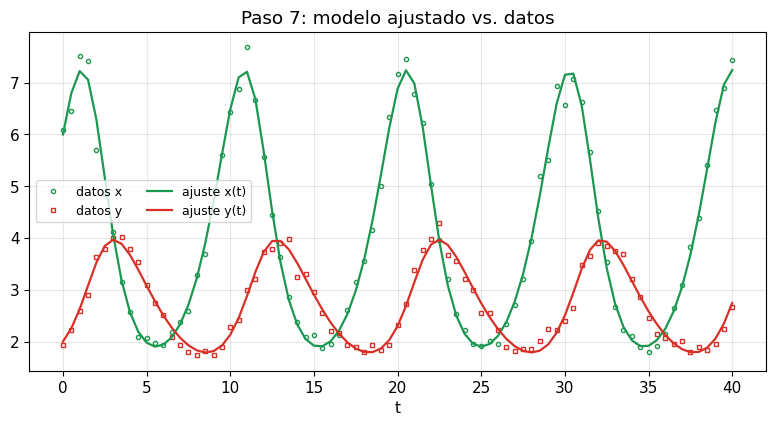

In [21]:
def resid(rho):
    theta = np.exp(rho)
    p = dict(alpha=theta[0], beta=theta[1], gamma=theta[2], delta=theta[3])
    _, xm, ym = simulate(p, X0_TRUE, Y0_TRUE, t_eval=DATA['t'], rtol=1e-6, atol=1e-6)
    return np.concatenate([xm - DATA['x'], ym - DATA['y']])

rng7 = np.random.default_rng(7)
theta_true_vec = np.array([P_TRUE['alpha'], P_TRUE['beta'], P_TRUE['gamma'], P_TRUE['delta']])
results = []
for k in range(6):
    guess = theta_true_vec * rng7.uniform(0.5, 2.0, 4)
    sol = least_squares(resid, np.log(guess), bounds=(-np.inf, np.inf),
                        method='trf', xtol=1e-10, ftol=1e-10, gtol=1e-10, max_nfev=400)
    results.append((2*sol.cost, np.exp(sol.x), sol.nfev))
results.sort(key=lambda r: r[0])
S_best, theta_best, nfev = results[0]

rows = "".join(
    f"<tr><td>{n}</td><td>{tv:.3f}</td><td>{tb:.3f}</td><td>{100*(tb-tv)/tv:+.1f}%</td></tr>"
    for n, tv, tb in zip(['alpha', 'beta', 'gamma', 'delta'], theta_true_vec, theta_best))
display(Markdown(
    f"**Mejor ajuste** (de {len(results)} arranques, $S_{{best}}={S_best:.1f}$, "
    f"{nfev} evals de EDO):<table><tr><th>parám</th><th>verdad</th><th>ajustado</th><th>error</th></tr>"
    f"{rows}</table>Esperado: errores del orden del ruido (≈5–10 %); $S/N\\approx$ varianza del ruido."))

_, xf, yf = simulate(dict(alpha=theta_best[0], beta=theta_best[1],
                          gamma=theta_best[2], delta=theta_best[3]),
                     X0_TRUE, Y0_TRUE, t_eval=DATA['t'])
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(DATA['t'], DATA['x'], 'o', ms=3, mfc='none', mec='#1a9850', label='datos x')
ax.plot(DATA['t'], DATA['y'], 's', ms=3, mfc='none', mec='#d73027', label='datos y')
ax.plot(DATA['t'], xf, '-', color='#1a9850', lw=1.6, label='ajuste x(t)')
ax.plot(DATA['t'], yf, '-', color='#d73027', lw=1.6, label='ajuste y(t)')
ax.set_xlabel('t'); ax.legend(ncol=2, fontsize=9)
ax.set_title('Paso 7: modelo ajustado vs. datos')
plt.show()

# Paso 8 · Robustez y plasticidad del comportamiento del modelo

Se perturba cada parámetro $p\to p(1+\varepsilon)$ y se mide el cambio **relativo** de métricas de
comportamiento $M$: punto fijo $(x^*,y^*)$, periodo lineal $T_{lin}$, periodo simulado $T_{sim}$ y
amplitud $A_x$. La **sensibilidad logarítmica** (coeficiente de control) es

$$S_{p}^{M}=\frac{\partial\ln M}{\partial\ln p}\approx
\frac{[M(p\cdot1.05)-M(p\cdot0.95)]/M(p)}{0.10}$$

**Resultados analíticos esperados (estructura de robustez):**
$S_\delta^{x^*}=+1$, $S_\gamma^{x^*}=-1$, $S_\alpha^{y^*}=+1$, $S_\beta^{y^*}=-1$,
$S_\alpha^{T}=S_\delta^{T}=-\tfrac12$, y $S=0$ para cualquier cruce resto‑parámetro/métrica
⇒ el modelo es **robusto** (insensible) a $\beta,\gamma$ en el periodo, pero **plástico** en las
amplitudes (fuertemente no lineal, depende de las CI).

**Uso del widget:** dropdown de parámetro + slider de $\varepsilon$ (%). **Interpretación
esperada:** perturbar $\alpha$ o $\delta$ cambia el *periodo* (curvas desfasadas); perturbar
$\gamma$ o $\beta$ cambia sobre todo la *amplitud/posición* de las órbitas pero casi no el periodo;
la tabla de sensibilidades reproduce los valores analíticos (±error numérico).

In [ ]:
def metrics(p, x0=6.0, y0=2.0, t_end=80.0):
    xs_, ys_ = eq_coexist(p)
    t, x, y = simulate(p, x0, y0, t_end=t_end, npts=2500)
    tail = t > 0.4*t_end                      # descarta transiente
    return dict(x_star=xs_, y_star=ys_, T_lin=period_lin(p),
                T_sim=sim_period(t[tail], x[tail]),
                A_x=0.5*(x[tail].max() - x[tail].min()))

M0 = metrics(P0)
PARAMS = ['alpha', 'beta', 'gamma', 'delta']
sens = {m: {} for m in M0}
for q in PARAMS:                              # sensibilidades logarítmicas (±5 %)
    pp = dict(P0); pp[q] = P0[q]*1.05; Mplus = metrics(pp)
    pm = dict(P0); pm[q] = P0[q]*0.95; Mminus = metrics(pm)
    for m in M0:
        sens[m][q] = ((Mplus[m] - Mminus[m])/M0[m]) / 0.10

tab = "<table><tr><th>Métrica</th>" + "".join(f"<th>S_{q}</th>" for q in PARAMS) + "</tr>"
for m in M0:
    tab += f"<tr><td>{m}</td>" + "".join(f"<td>{sens[m][q]:+.2f}</td>" for q in PARAMS) + "</tr>"
display(Markdown("**Sensibilidades logarítmicas $S_p^M$ (±5 %):**" + tab +
                 "<br>Esperado: $S_\\delta^{x^*}=+1$, $S_\\gamma^{x^*}=-1$, $S_\\alpha^{y^*}=+1$, "
                 "$S_\\beta^{y^*}=-1$, $S_\\alpha^{T}=S_\\delta^{T}=-0.5$, ceros en el resto."))

w_p8 = widgets.Dropdown(options=PARAMS, value='alpha', description='Perturbar:')
w_e8 = widgets.FloatSlider(value=0.0, min=-50.0, max=50.0, step=1.0,
                           description='ε (%)', continuous_update=False)

def perturb_plot(param, eps):
    pp = dict(P0); pp[param] = P0[param]*(1 + eps/100.0)
    t0, x0s, y0s = simulate(P0, 6.0, 2.0, t_end=60, npts=1800)
    t1, x1s, y1s = simulate(pp, 6.0, 2.0, t_end=60, npts=1800)
    M1 = metrics(pp)
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
    axes[0].plot(t0, x0s, '-', color='#1a9850', lw=1.2, label='x base')
    axes[0].plot(t1, x1s, '--', color='#1a9850', lw=1.4, label=f'x perturb ({eps:+.0f}%)')
    axes[0].plot(t0, y0s, '-', color='#d73027', lw=1.2, label='y base')
    axes[0].plot(t1, y1s, '--', color='#d73027', lw=1.4, label='y perturb')
    axes[0].set_xlabel('t'); axes[0].legend(fontsize=8, ncol=2)
    axes[0].set_title(f'Perturbación de {param}')
    axes[1].plot(x0s, y0s, '-', lw=1.2, label='órbita base')
    axes[1].plot(x1s, y1s, '--', lw=1.4, label='órbita perturbada')
    axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].legend(fontsize=8)
    axes[1].set_title(f"T_sim: {M0['T_sim']:.2f} → {M1['T_sim']:.2f} | "
                      f"A_x: {M0['A_x']:.2f} → {M1['A_x']:.2f}")
    fig.tight_layout()
    return fig

interactive_plot({'param': w_p8, 'eps': w_e8}, widgets.VBox([w_p8, w_e8]), perturb_plot)

**Sensibilidades logarítmicas $S_p^M$ (±5 %):**<table><tr><th>Métrica</th><th>S_alpha</th><th>S_beta</th><th>S_gamma</th><th>S_delta</th></tr><tr><td>x_star</td><td>+0.00</td><td>+0.00</td><td>-1.00</td><td>+1.00</td></tr><tr><td>y_star</td><td>+1.00</td><td>-1.00</td><td>+0.00</td><td>+0.00</td></tr><tr><td>T_lin</td><td>-0.50</td><td>+0.00</td><td>+0.00</td><td>-0.50</td></tr><tr><td>T_sim</td><td>-0.42</td><td>-0.08</td><td>+0.06</td><td>-0.56</td></tr><tr><td>A_x</td><td>+2.03</td><td>-1.74</td><td>+0.16</td><td>-0.45</td></tr><br>Esperado: $S_\delta^{x^*}=+1$, $S_\gamma^{x^*}=-1$, $S_\alpha^{y^*}=+1$, $S_\beta^{y^*}=-1$, $S_\alpha^{T}=S_\delta^{T}=-0.5$, ceros en el resto.

Output()

# Síntesis del flujo de trabajo

| Paso | Pregunta | Herramienta computacional | Resultado clave |
|---|---|---|---|
| 1 | ¿Quién interactúa con quién? | grafo de reacciones | R1–R4 y modificadores |
| 2 | ¿Cómo se escribe? | acción de masas | EDOs no lineales (orden 1 y 2) |
| 3 | ¿Qué se conserva? | sympy + primera integral | $V$ constante → órbitas cerradas; 1 parámetro adimensional |
| 4 | ¿Contra qué valido? | datos sintéticos + métricas | oscilación, desfase $T/4$, promedios = punto fijo |
| 5 | ¿Dónde se queda? | Jacobiano + eigenvalores | silla en (0,0); centro ±i√(αδ) |
| 6 | ¿Cómo evoluciona? | `solve_ivp` (LSODA) | ciclos sostenidos, deriva de $V$ ≈ error numérico |
| 7 | ¿Qué θ explica los datos? | `least_squares` + multi‑start | recuperación de $P_{true}$ dentro del ruido |
| 8 | ¿Qué tan confiable? | sensibilidades logarítmicas | robustez estructural (periodo) vs. plasticidad (amplitud) |

**Nota:** el mismo diagrama del Paso 1 determina *todo* lo demás; cada decisión de
abstracción (orden 1 vs. orden 2, modificadores, sin generación espontánea) se traduce en una
propiedad dinámica verificable computacionalmente.